# Loading the data

In [1]:
import pandas as pd

photos_raw = pd.read_parquet("../data/raw/photos.parquet")
photos_raw.head()

,observation_id,photo_id,photo_license_code,url,square_url,small_url,medium_url,large_url,original_url
0,55574,86869,cc-by,https://inaturalist-open-data.s3.amazonaws.com...,None,None,None,None,None
1,55575,86870,cc-by,https://inaturalist-open-data.s3.amazonaws.com...,None,None,None,None,None
2,338604,421440,cc-by-nc,https://inaturalist-open-data.s3.amazonaws.com...,None,None,None,None,None
3,338604,421441,cc-by-nc,https://inaturalist-open-data.s3.amazonaws.com...,None,None,None,None,None
4,338604,421442,cc-by-nc,https://inaturalist-open-data.s3.amazonaws.com...,None,None,None,None,None


In [2]:
photos = photos_raw.copy()

# Photos EDA

In [3]:
photos.info()

<class 'pandas.DataFrame'>
RangeIndex: 28544 entries, 0 to 28543
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   observation_id      28544 non-null  int64 
 1   photo_id            28544 non-null  int64 
 2   photo_license_code  28544 non-null  str   
 3   url                 28544 non-null  str   
 4   square_url          0 non-null      object
 5   small_url           0 non-null      object
 6   medium_url          0 non-null      object
 7   large_url           0 non-null      object
 8   original_url        0 non-null      object
dtypes: int64(2), object(5), str(2)
memory usage: 4.2+ MB


## Drop Unnecesary columns

In [4]:
photos = photos.drop(
    columns=["square_url", "small_url", "medium_url", "large_url", "original_url"]
)
photos.info()

<class 'pandas.DataFrame'>
RangeIndex: 28544 entries, 0 to 28543
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   observation_id      28544 non-null  int64
 1   photo_id            28544 non-null  int64
 2   photo_license_code  28544 non-null  str  
 3   url                 28544 non-null  str  
dtypes: int64(2), str(2)
memory usage: 3.1 MB


## Photo License distribution

In [5]:
photos["photo_license_code"].value_counts()

photo_license_code
cc-by-nc       19941
cc-by           6831
cc0              850
cc-by-nc-nd      390
cc-by-nc-sa      376
cc-by-sa         154
cc-by-nd           2
Name: count, dtype: int64

## Join the photos and observation

In [6]:
photos.rename(columns={"observation_id": "obs_id"}, inplace=True)

In [7]:
photos.info()

<class 'pandas.DataFrame'>
RangeIndex: 28544 entries, 0 to 28543
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   obs_id              28544 non-null  int64
 1   photo_id            28544 non-null  int64
 2   photo_license_code  28544 non-null  str  
 3   url                 28544 non-null  str  
dtypes: int64(2), str(2)
memory usage: 3.1 MB


In [8]:
obs_raw = pd.read_parquet("../data/interim/clean_obs.parquet")
obs_raw.head()

,obs_id,obs_url,quality_grade,obs_license_code,predator_prey_role,scientific_name,taxon_rank,common_name,latitude,longitude,...,subfamily_name,hybrid_name,complex_name,form_name,subgenus_name,variety_name,tribe_name,country,state,city
0,55574,http://www.inaturalist.org/observations/55574,research,cc-by,predator,Korthalsella complanata,species,Kaumahana,21.317598,-157.743287,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,United States,Hawaii,Honolulu
1,55575,http://www.inaturalist.org/observations/55575,research,cc-by,prey,Syzygium sandwicense,species,ʻōhiʻa ha,21.317598,-157.743287,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,United States,Hawaii,Honolulu
2,338604,http://conabio.inaturalist.org/observations/33...,research,cc-by-nc,predator,Geococcyx californianus,species,Greater Roadrunner,25.557155,-103.453939,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Mexico,Coahuila,Torreón
3,414645,http://www.inaturalist.org/observations/414645,research,cc-by,predator,Lycophidion capense,species,Cape Wolf Snake,-15.836848,29.146428,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Zimbabwe,Mashonaland West Province,Hurungwe 7
4,414707,http://www.inaturalist.org/observations/414707,research,cc-by,prey,Mochlus sundevallii,species,Sundevall's Writhing Skink,-15.836848,29.146428,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Zimbabwe,Mashonaland West Province,Hurungwe 7


In [9]:
photo_obs = photos.merge(obs_raw, on="obs_id", how="left")
photo_obs.info()

<class 'pandas.DataFrame'>
RangeIndex: 28544 entries, 0 to 28543
Data columns (total 33 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   obs_id               28544 non-null  int64  
 1   photo_id             28544 non-null  int64  
 2   photo_license_code   28544 non-null  str    
 3   url                  28544 non-null  str    
 4   obs_url              28544 non-null  str    
 5   quality_grade        28544 non-null  str    
 6   obs_license_code     28544 non-null  str    
 7   predator_prey_role   28279 non-null  str    
 8   scientific_name      28544 non-null  str    
 9   taxon_rank           28544 non-null  str    
 10  common_name          25889 non-null  str    
 11  latitude             28453 non-null  float64
 12  longitude            28453 non-null  float64
 13  positional_accuracy  23055 non-null  float64
 14  photo_count          28544 non-null  int64  
 15  kingdom_name         28544 non-null  str    
 1

In [10]:
obs_list = obs_raw[["obs_id", "kingdom_name", "scientific_name", "photo_count"]]
photo_list = photos["obs_id"].unique().tolist()
obs_list["has_photo"] = obs_list["obs_id"].isin(photo_list)

obs_list[~obs_list["has_photo"]]

,obs_id,kingdom_name,scientific_name,photo_count,has_photo
40,1187949,Animalia,Sigmodon hispidus,3,False
88,4615033,Animalia,Syncerus caffer caffer,4,False
100,4977021,Animalia,Octopus tetricus,3,False
102,5020579,Animalia,Pomoxis nigromaculatus,1,False
137,6970344,Animalia,Ardea herodias,1,False
...,...,...,...,...,...
10292,399553052,Plantae,Liatris ligulistylis,2,False
10306,400001445,Plantae,Trifolium hybridum,1,False
10316,400343439,Animalia,Etheostoma flabellare,2,False
10352,401727961,Animalia,Omphalocera munroei,1,False


# ----Need to check why 586 dont have photos -----

In [11]:
photo_obs

,obs_id,photo_id,photo_license_code,url,obs_url,quality_grade,obs_license_code,predator_prey_role,scientific_name,taxon_rank,...,subfamily_name,hybrid_name,complex_name,form_name,subgenus_name,variety_name,tribe_name,country,state,city
0,55574,86869,cc-by,https://inaturalist-open-data.s3.amazonaws.com...,http://www.inaturalist.org/observations/55574,research,cc-by,predator,Korthalsella complanata,species,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,United States,Hawaii,Honolulu
1,55575,86870,cc-by,https://inaturalist-open-data.s3.amazonaws.com...,http://www.inaturalist.org/observations/55575,research,cc-by,prey,Syzygium sandwicense,species,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,United States,Hawaii,Honolulu
2,338604,421440,cc-by-nc,https://inaturalist-open-data.s3.amazonaws.com...,http://conabio.inaturalist.org/observations/33...,research,cc-by-nc,predator,Geococcyx californianus,species,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Mexico,Coahuila,Torreón
3,338604,421441,cc-by-nc,https://inaturalist-open-data.s3.amazonaws.com...,http://conabio.inaturalist.org/observations/33...,research,cc-by-nc,predator,Geococcyx californianus,species,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Mexico,Coahuila,Torreón
4,338604,421442,cc-by-nc,https://inaturalist-open-data.s3.amazonaws.com...,http://conabio.inaturalist.org/observations/33...,research,cc-by-nc,predator,Geococcyx californianus,species,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Mexico,Coahuila,Torreón
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28539,402894441,739677854,cc-by-nc,https://inaturalist-open-data.s3.amazonaws.com...,https://www.inaturalist.org/observations/40289...,research,cc-by-nc,predator,Tenodera sinensis,species,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,United States,Massachusetts,Middlesex
28540,402958990,739800777,cc-by-nc,https://inaturalist-open-data.s3.amazonaws.com...,https://www.inaturalist.org/observations/40295...,research,cc-by-nc,prey,Arctotheca calendula,species,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Australia,Victoria,Yarra Ranges
28541,402961424,739804657,cc-by-nc,https://inaturalist-open-data.s3.amazonaws.com...,https://www.inaturalist.org/observations/40296...,research,cc-by-nc,predator,Cyprotides cyprotus,species,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Australia,New South Wales,Northern Beaches
28542,402961544,739804919,cc-by-nc,https://inaturalist-open-data.s3.amazonaws.com...,https://www.inaturalist.org/observations/40296...,research,cc-by-nc,predator,Vanessa kershawi,species,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Australia,New South Wales,Northern Beaches


In [12]:
animalia = photo_obs[photo_obs["kingdom_name"] == "Animalia"]
animalia.info()

<class 'pandas.DataFrame'>
Index: 23125 entries, 2 to 28542
Data columns (total 33 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   obs_id               23125 non-null  int64  
 1   photo_id             23125 non-null  int64  
 2   photo_license_code   23125 non-null  str    
 3   url                  23125 non-null  str    
 4   obs_url              23125 non-null  str    
 5   quality_grade        23125 non-null  str    
 6   obs_license_code     23125 non-null  str    
 7   predator_prey_role   22860 non-null  str    
 8   scientific_name      23125 non-null  str    
 9   taxon_rank           23125 non-null  str    
 10  common_name          21250 non-null  str    
 11  latitude             23039 non-null  float64
 12  longitude            23039 non-null  float64
 13  positional_accuracy  18795 non-null  float64
 14  photo_count          23125 non-null  int64  
 15  kingdom_name         23125 non-null  str    
 16  ph

# Charcterization questions on the final dataset

## Licensed observation distribution

In [13]:
# Check observation license distribution for unique observation IDs
obs_license_distribution = (
    animalia.drop_duplicates(subset="obs_id")["obs_license_code"]
    .value_counts(dropna=False)
    .reset_index()
)

obs_license_distribution


,obs_license_code,count
0,cc-by-nc,4842
1,cc-by,2395
2,cc0,341
3,cc-by-nc-nd,125
4,cc-by-nc-sa,92
5,cc-by-sa,35
6,cc-by-nd,2


In [14]:
supported_licenses = [
    "cc-by-nc",
    "cc-by-sa",
    "cc-by-nd",
    "cc-by",
    "cc-by-nc",
    "cc-by-nc-sa",
    "cc-by-nc-nd",
    "cc0",
]
unsupported_licenses_count = animalia.loc[
    ~animalia["obs_license_code"].isin(supported_licenses), "obs_license_code"
].count()
print(f"Unsupported licenses count: {unsupported_licenses_count}")

Unsupported licenses count: 0


## Licensed photo distribution

In [15]:
# Check observation license distribution for photo IDs
photo_license_distribution = (
    animalia.drop_duplicates(subset="photo_id")["photo_license_code"]
    .value_counts(dropna=False)
    .reset_index()
)

photo_license_distribution

,photo_license_code,count
0,cc-by-nc,16514
1,cc-by,5157
2,cc0,613
3,cc-by-nc-nd,379
4,cc-by-nc-sa,311
5,cc-by-sa,151


In [16]:
supported_licenses = [
    "cc-by-nc",
    "cc-by-sa",
    "cc-by-nd",
    "cc-by",
    "cc-by-nc",
    "cc-by-nc-sa",
    "cc-by-nc-nd",
    "cc0",
]
unsupported_licenses_photo_count = animalia.loc[
    ~animalia["photo_license_code"].isin(supported_licenses), "photo_license_code"
].count()
print(f"Unsupported licenses count: {unsupported_licenses_count}")

Unsupported licenses count: 0


## photo count distribution

In [17]:
photo_count = (
    animalia.groupby("obs_id")["photo_id"]
    .count()
    .reset_index(name="photo_count")
    .sort_values(by="photo_count", ascending=False)
)
photo_count


,obs_id,photo_count
1601,94545153,33
805,57943056,32
1349,75686957,30
7790,401138678,29
2182,126678837,27
...,...,...
4846,250400748,1
4844,250312916,1
4843,250312915,1
4842,250273407,1


In [11]:
obs = animalia.groupby("taxon_rank")["obs_id"].nunique().sort_values(ascending=False)

obs

taxon_rank
species       6702
subspecies     918
genus          100
hybrid          44
variety         24
complex         19
subgenus        10
tribe            7
subfamily        5
form             3
Name: obs_id, dtype: int64

In [126]:
photo_dist = photo_count.describe().rename_axis(index="statistic")
photo_dist

,obs_id,photo_count
statistic,,
count,7.832000e+03,7832.000000
mean,2.087945e+08,2.952630
std,1.124501e+08,2.897108
min,3.386040e+05,1.000000
25%,1.106266e+08,1.000000
50%,2.107229e+08,2.000000
75%,3.070840e+08,4.000000
max,4.029615e+08,33.000000


In [19]:
print(
    f"The total number of images in the dataset is : {photo_count['photo_count'].sum()}"
)

The total number of images in the dataset is : 23125


In [20]:
dist_val = photo_count["photo_count"].value_counts().sort_index().reset_index()
dist_val.columns = ["photos_per_observation", "observation_count"]
dist_val

,photos_per_observation,observation_count
0,1,2971
1,2,1693
2,3,1117
3,4,706
4,5,417
5,6,240
6,7,185
7,8,133
8,9,83
9,10,66


In [21]:
photo_count_summary = pd.Series(
    {
        "1": dist_val.loc[
            dist_val["photos_per_observation"] == 1, "observation_count"
        ].sum(),
        "2": dist_val.loc[
            dist_val["photos_per_observation"] == 2, "observation_count"
        ].sum(),
        "3+": dist_val.loc[
            dist_val["photos_per_observation"] >= 3, "observation_count"
        ].sum(),
    }
)


print(photo_count_summary)

1     2971
2     1693
3+    3168
dtype: int64


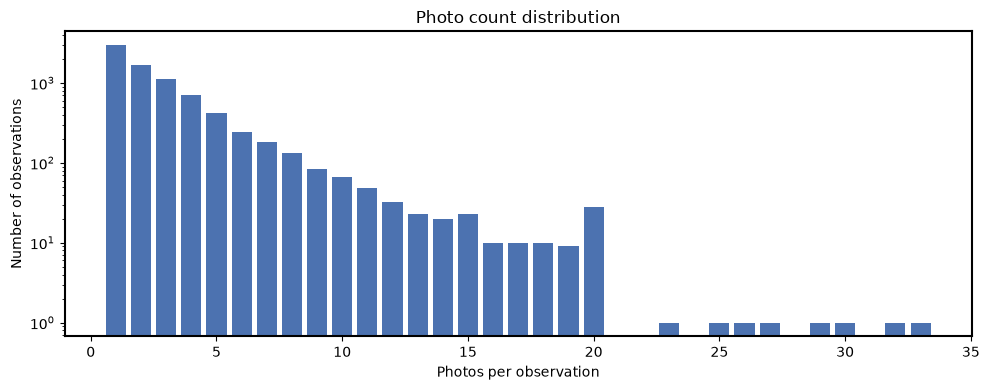

In [22]:
# Distribution of photo count per observation
import matplotlib.pyplot as plt

photo_counts = photo_count["photo_count"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(10, 4))

ax.bar(photo_counts.index, photo_counts.values, color="#4C72B0")

ax.set_xlabel("Photos per observation")
ax.set_ylabel("Number of observations")
ax.set_title("Photo count distribution")
ax.set_yscale("log")

# Show all four borders
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color("black")
    spine.set_linewidth(1.5)

plt.tight_layout()
plt.show()


## Taxon Rank Column Distribution

In [26]:
required_taxon = [
    "taxon_rank",
    "scientific_name",
    "kingdom_name",
    "phylum_name",
    "class_name",
    "order_name",
    "family_name",
    "genus_name",
    "species_name",
    "subspecies_name",
    "hybrid_name",
    "variety_name",
    "complex_name",
    "subgenus_name",
    "tribe_name",
    "subfamily_name",
    "form_name",
]

In [36]:
animalia["taxon_rank"].value_counts().reset_index().sort_values(
    by="count", ascending=False
)

,taxon_rank,count
0,species,19400
1,subspecies,3217
2,genus,262
3,hybrid,69
4,variety,53
5,complex,40
6,subgenus,33
7,tribe,25
8,subfamily,19
9,form,7


In [ ]:
animalia[animalia["taxon_rank"] != "species"]

,obs_id,photo_id,photo_license_code,url,obs_url,quality_grade,obs_license_code,predator_prey_role,scientific_name,taxon_rank,...,subfamily_name,hybrid_name,complex_name,form_name,subgenus_name,variety_name,tribe_name,country,state,city
12,465679,587403,cc-by,https://inaturalist-open-data.s3.amazonaws.com...,http://www.inaturalist.org/observations/465679,research,cc-by,predator,Lutra capensis capensis,subspecies,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Zimbabwe,Mashonaland Central Province,Goromonzi 4
25,613368,773134,cc-by,https://inaturalist-open-data.s3.amazonaws.com...,http://www.inaturalist.org/observations/613368,research,cc-by,predator,Papilio nireus lyaeus,subspecies,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Malawi,Southern Region,Inhamitanga
26,613370,773135,cc-by,https://inaturalist-open-data.s3.amazonaws.com...,http://www.inaturalist.org/observations/613370,research,cc-by,predator,Papilio nireus lyaeus,subspecies,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Malawi,Southern Region,Inhamitanga
51,893936,1136774,cc-by,https://inaturalist-open-data.s3.amazonaws.com...,http://www.inaturalist.org/observations/893936,research,cc-by,prey,Lycaon pictus pictus,subspecies,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Zimbabwe,Mashonaland West Province,Hurungwe 7
52,893936,1136775,cc-by,https://inaturalist-open-data.s3.amazonaws.com...,http://www.inaturalist.org/observations/893936,research,cc-by,prey,Lycaon pictus pictus,subspecies,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Zimbabwe,Mashonaland West Province,Hurungwe 7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28523,402870238,739612157,cc-by-nc-sa,https://inaturalist-open-data.s3.amazonaws.com...,https://www.inaturalist.org/observations/40287...,research,cc-by-nc-sa,predator,Buteo jamaicensis borealis,subspecies,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Canada,Ontario,Toronto
28524,402870238,739612169,cc-by-nc-sa,https://inaturalist-open-data.s3.amazonaws.com...,https://www.inaturalist.org/observations/40287...,research,cc-by-nc-sa,predator,Buteo jamaicensis borealis,subspecies,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Canada,Ontario,Toronto
28525,402870238,739612175,cc-by-nc-sa,https://inaturalist-open-data.s3.amazonaws.com...,https://www.inaturalist.org/observations/40287...,research,cc-by-nc-sa,predator,Buteo jamaicensis borealis,subspecies,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Canada,Ontario,Toronto
28526,402870238,739612199,cc-by-nc-sa,https://inaturalist-open-data.s3.amazonaws.com...,https://www.inaturalist.org/observations/40287...,research,cc-by-nc-sa,predator,Buteo jamaicensis borealis,subspecies,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Canada,Ontario,Toronto


In [33]:
animalia[["obs_id", *required_taxon]].info()

<class 'pandas.DataFrame'>
Index: 23125 entries, 2 to 28542
Data columns (total 18 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   obs_id           23125 non-null  int64
 1   taxon_rank       23125 non-null  str  
 2   scientific_name  23125 non-null  str  
 3   kingdom_name     23125 non-null  str  
 4   phylum_name      23125 non-null  str  
 5   class_name       23065 non-null  str  
 6   order_name       23087 non-null  str  
 7   family_name      23121 non-null  str  
 8   genus_name       262 non-null    str  
 9   species_name     22677 non-null  str  
 10  subspecies_name  3217 non-null   str  
 11  hybrid_name      69 non-null     str  
 12  variety_name     53 non-null     str  
 13  complex_name     40 non-null     str  
 14  subgenus_name    33 non-null     str  
 15  tribe_name       25 non-null     str  
 16  subfamily_name   19 non-null     str  
 17  form_name        7 non-null      str  
dtypes: int64(1), str(17)
m

## Taxonomic compositions

In [39]:
animalia.head()

,obs_id,photo_id,photo_license_code,url,obs_url,quality_grade,obs_license_code,predator_prey_role,scientific_name,taxon_rank,...,subfamily_name,hybrid_name,complex_name,form_name,subgenus_name,variety_name,tribe_name,country,state,city
2,338604,421440,cc-by-nc,https://inaturalist-open-data.s3.amazonaws.com...,http://conabio.inaturalist.org/observations/33...,research,cc-by-nc,predator,Geococcyx californianus,species,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Mexico,Coahuila,Torreón
3,338604,421441,cc-by-nc,https://inaturalist-open-data.s3.amazonaws.com...,http://conabio.inaturalist.org/observations/33...,research,cc-by-nc,predator,Geococcyx californianus,species,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Mexico,Coahuila,Torreón
4,338604,421442,cc-by-nc,https://inaturalist-open-data.s3.amazonaws.com...,http://conabio.inaturalist.org/observations/33...,research,cc-by-nc,predator,Geococcyx californianus,species,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Mexico,Coahuila,Torreón
5,338604,421443,cc-by-nc,https://inaturalist-open-data.s3.amazonaws.com...,http://conabio.inaturalist.org/observations/33...,research,cc-by-nc,predator,Geococcyx californianus,species,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Mexico,Coahuila,Torreón
6,414645,521779,cc-by,https://inaturalist-open-data.s3.amazonaws.com...,http://www.inaturalist.org/observations/414645,research,cc-by,predator,Lycophidion capense,species,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Zimbabwe,Mashonaland West Province,Hurungwe 7


### Unique count in each ranks?

In [40]:
def unique_ranks(df):
    ranks = [
        "kingdom_name",
        "phylum_name",
        "class_name",
        "order_name",
        "family_name",
        "genus_name",
        "species_name",
    ]

    for rank in ranks:
        print(f"Unique {rank.replace('_name', '').capitalize()}: {df[rank].nunique()}")


unique_ranks(animalia)

Unique Kingdom: 1
Unique Phylum: 9
Unique Class: 29
Unique Order: 144
Unique Family: 613
Unique Genus: 69
Unique Species: 2992


### What percentage of observations belong to each major class/order/family?

In [41]:
def percentage_obs_ranks(df, rank_name, count=None):
    rank = (
        df[rank_name]
        .value_counts()
        .sort_values(ascending=False)
        .reset_index(name="count")
    )
    rank["percentage"] = round((rank["count"] / df.shape[0]) * 100, 2)
    display(rank.head(count) if count is not None else rank)

In [42]:
percentage_obs_ranks(animalia, "phylum_name", 5)

,phylum_name,count,percentage
0,Chordata,12580,54.40
1,Arthropoda,10164,43.95
2,Mollusca,217,0.94
3,Echinodermata,77,0.33
4,Onychophora,38,0.16


In [43]:
percentage_obs_ranks(animalia, "class_name", 5)

,class_name,count,percentage
0,Aves,8433,36.47
1,Insecta,7785,33.66
2,Arachnida,2076,8.98
3,Mammalia,1642,7.10
4,Reptilia,1416,6.12


In [44]:
percentage_obs_ranks(animalia, "order_name", 5)

,order_name,count,percentage
0,Passeriformes,2585,11.18
1,Hymenoptera,2240,9.69
2,Lepidoptera,2180,9.43
3,Araneae,1725,7.46
4,Squamata,1218,5.27


In [45]:
percentage_obs_ranks(animalia, "family_name", 5)

,family_name,count,percentage
0,Apidae,924,4.00
1,Accipitridae,835,3.61
2,Ardeidae,790,3.42
3,Alcedinidae,647,2.80
4,Laridae,602,2.60


In [46]:
percentage_obs_ranks(animalia, "genus_name", 5)

,genus_name,count,percentage
0,Liriomyza,14,0.06
1,Uroleucon,12,0.05
2,Bombus,11,0.05
3,Lucilia,10,0.04
4,Misumenoides,10,0.04


In [47]:
percentage_obs_ranks(animalia, "species_name", 5)

,species_name,count,percentage
0,Halcyon albiventris,460,1.99
1,Ardea herodias,327,1.41
2,Apis mellifera,302,1.31
3,Pandion haliaetus,271,1.17
4,Passer domesticus,216,0.93


In [48]:
class_counts = (
    animalia.dropna(subset=["class_name"])
    .groupby("class_name")["obs_id"]
    .nunique()
    .sort_values(ascending=False)
)

top_n = 12
class_plot = pd.concat(
    [
        class_counts.head(top_n),
        pd.Series({"Other": class_counts.iloc[top_n:].sum()}),
    ]
)

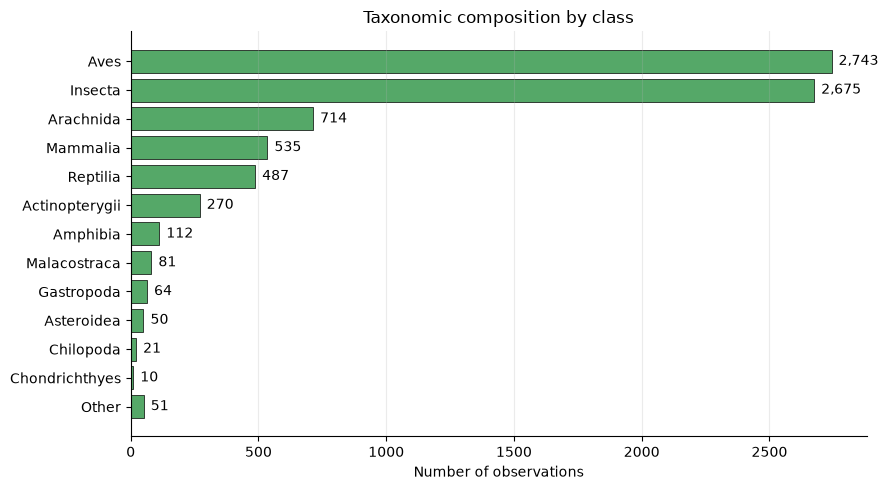

In [49]:
fig, ax = plt.subplots(figsize=(9, 5))

bars = ax.barh(
    class_plot.index,
    class_plot.values,
    color="#55A868",
    edgecolor="black",
    linewidth=0.5,
)

ax.invert_yaxis()
ax.set_xlabel("Number of observations")
ax.set_title("Taxonomic composition by class")

for bar, count in zip(bars, class_plot.values):
    ax.text(
        count + class_plot.max() * 0.01,
        bar.get_y() + bar.get_height() / 2,
        f"{count:,}",
        va="center",
    )

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="x", alpha=0.25)

plt.tight_layout()
plt.show()

### What are the observation and photo count distribution under animalia for each phylum?

In [50]:
animalia["phylum_name"].unique()

<ArrowStringArray>
[       'Chordata',      'Arthropoda',   'Echinodermata',        'Mollusca',
        'Cnidaria',        'Nemertea',        'Annelida', 'Platyhelminthes',
     'Onychophora']
Length: 9, dtype: str

In [53]:
print(f"Observation distribution per phylum under animalia")
animalia.groupby("phylum_name")["obs_id"].nunique().sort_values(ascending=False)


Observation distribution per phylum under animalia


phylum_name
Chordata           4159
Arthropoda         3508
Mollusca             77
Echinodermata        58
Onychophora          11
Platyhelminthes       8
Cnidaria              6
Annelida              4
Nemertea              1
Name: obs_id, dtype: int64

In [54]:
print(f"Photo count distribution per phylum under animalia")
animalia.groupby("phylum_name")["photo_id"].count().sort_values(ascending=False)

Photo count distribution per phylum under animalia


phylum_name
Chordata           12580
Arthropoda         10164
Mollusca             217
Echinodermata         77
Onychophora           38
Platyhelminthes       22
Annelida              15
Cnidaria               8
Nemertea               4
Name: photo_id, dtype: int64

### What percentage of images belong to each major phylum group?


In [55]:
def per_img_rank(df, rank_name, count=None):
    rank = (
        df.groupby(rank_name)["photo_id"]
        .count()
        .sort_values(ascending=False)
        .reset_index(name="count")
    )
    display(rank.head(count) if count is not None else rank)

In [56]:
per_img_rank(animalia, "phylum_name")

,phylum_name,count
0,Chordata,12580
1,Arthropoda,10164
2,Mollusca,217
3,Echinodermata,77
4,Onychophora,38
5,Platyhelminthes,22
6,Annelida,15
7,Cnidaria,8
8,Nemertea,4


### How many species have:- 1, 2 to 5 observations, 6 to 10, 11 to 50, 50

In [62]:
obs_per_species = (
    animalia.groupby("species_name")["obs_id"]
    .nunique()
    .reset_index(name="observation_count")
    .sort_values(by="observation_count", ascending=False)
)

obs_per_species

,species_name,observation_count
224,Apis mellifera,145
1208,Halcyon albiventris,107
28,Aceria theospyri,103
1979,Pandion haliaetus,92
252,Ardea herodias,82
...,...,...
2991,Zyxomma petiolatum,1
2989,Zygaena loti,1
2987,Zygaena ephialtes,1
2986,Zygaena corsica,1


In [67]:
one_obs = obs_per_species[obs_per_species["observation_count"] == 1][
    "species_name"
].nunique()
print(f"Number of species with only one observation: {one_obs}")

one_obs = obs_per_species[
    (obs_per_species["observation_count"] >= 2)
    & (obs_per_species["observation_count"] <= 5)
]["species_name"].nunique()
print(f"Number of species with 2 to 5 observations: {one_obs}")

one_obs = obs_per_species[
    (obs_per_species["observation_count"] >= 6)
    & (obs_per_species["observation_count"] <= 10)
]["species_name"].nunique()
print(f"Number of species with 6 to 10 observations: {one_obs}")

one_obs = obs_per_species[
    (obs_per_species["observation_count"] >= 11)
    & (obs_per_species["observation_count"] <= 50)
]["species_name"].nunique()
print(f"Number of species with 11 to 50 observations: {one_obs}")

one_obs = obs_per_species[
    (obs_per_species["observation_count"] >= 51)
    & (obs_per_species["observation_count"] <= 100)
]["species_name"].nunique()
print(f"Number of species with 51 to 100 observations: {one_obs}")

one_obs = obs_per_species[
    (obs_per_species["observation_count"] >= 101)
    & (obs_per_species["observation_count"] <= 300)
]["species_name"].nunique()
print(f"Number of species with 101 to 300 observations: {one_obs}")

Number of species with only one observation: 1854
Number of species with 2 to 5 observations: 906
Number of species with 6 to 10 observations: 153
Number of species with 11 to 50 observations: 72
Number of species with 51 to 100 observations: 4
Number of species with 101 to 300 observations: 3


Observation per species distribution

In [64]:
import matplotlib.pyplot as plt

species_obs_counts = (
    animalia.dropna(subset=["species_name"])
    .groupby("species_name")["obs_id"]
    .nunique()
    .sort_values(ascending=False)
)

species_count_distribution = (
    species_obs_counts.value_counts()
    .sort_index()
    .rename_axis("observations_per_species")
    .reset_index(name="species_count")
)

print(f"Number of species: {species_obs_counts.shape[0]}")
print(f"Median observations per species: {species_obs_counts.median():.0f}")
print(f"Mean observations per species: {species_obs_counts.mean():.2f}")
print(f"Species with 1 observation: {(species_obs_counts == 1).sum()}")
print(f"Species with fewer than 5 observations: {(species_obs_counts < 5).sum()}")


Number of species: 2992
Median observations per species: 1
Mean observations per species: 2.56
Species with 1 observation: 1854
Species with fewer than 5 observations: 2678


In [65]:
display(species_count_distribution.head(10))


,observations_per_species,species_count
0,1,1854
1,2,485
2,3,228
3,4,111
4,5,82
5,6,51
6,7,39
7,8,22
8,9,24
9,10,17


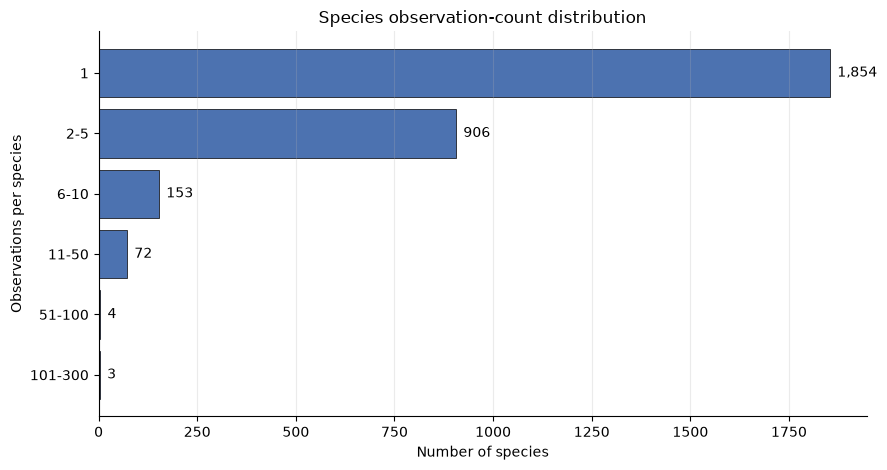

In [68]:
import matplotlib.pyplot as plt

bin_edges = [0, 1, 5, 10, 50, 100, 300]
bin_labels = ["1", "2-5", "6-10", "11-50", "51-100", "101-300"]

species_obs_bins = (
    pd.cut(
        species_obs_counts,
        bins=bin_edges,
        labels=bin_labels,
        include_lowest=True,
    )
    .value_counts()
    .sort_index()
)

fig, ax = plt.subplots(figsize=(9, 4.8))

bars = ax.barh(
    species_obs_bins.index.astype(str),
    species_obs_bins.values,
    color="#4C72B0",
    edgecolor="black",
    linewidth=0.5,
)

ax.invert_yaxis()

ax.set_xlabel("Number of species")
ax.set_ylabel("Observations per species")
ax.set_title("Species observation-count distribution")

for bar, count in zip(bars, species_obs_bins.values):
    ax.text(
        count + species_obs_bins.max() * 0.01,
        bar.get_y() + bar.get_height() / 2,
        f"{count:,}",
        va="center",
        fontsize=10,
    )

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="x", alpha=0.25)

plt.tight_layout()
plt.show()

### What proportion of all images comes from the top 1%, 5%, and 10% most common species?

In [69]:
import numpy as np

# One row per species: observation count + image count
species_summary = (
    animalia.dropna(subset=["species_name"])
    .groupby("species_name")
    .agg(
        observation_count=("obs_id", "nunique"),
        image_count=("photo_id", "nunique"),
    )
    .sort_values("observation_count", ascending=False)
)

total_images = species_summary["image_count"].sum()

for pct in [0.01, 0.05, 0.10, 0.30, 0.50]:
    n_species = max(1, int(np.ceil(len(species_summary) * pct)))
    top_images = species_summary.head(n_species)["image_count"].sum()
    image_share = top_images / total_images * 100

    print(
        f"Top {int(pct * 100)}% species "
        f"({n_species:,} species): {top_images:,} images "
        f"({image_share:.2f}% of all images)"
    )

Top 1% species (30 species): 3,711 images (16.36% of all images)
Top 5% species (150 species): 7,491 images (33.03% of all images)
Top 10% species (300 species): 10,007 images (44.13% of all images)
Top 30% species (898 species): 15,140 images (66.76% of all images)
Top 50% species (1,496 species): 17,747 images (78.26% of all images)


##  Predator versus prey composition

In [70]:
animalia["predator_prey_role"].unique()

<ArrowStringArray>
['predator', 'prey', nan]
Length: 3, dtype: str

In [72]:
pre_prey = animalia["predator_prey_role"].value_counts().reset_index()
pre_prey.columns = ["predator_prey_role", "image_count"]
pre_prey["Percentage"] = round(
    (pre_prey["image_count"] / pre_prey["image_count"].sum()) * 100, 2
)
pre_prey

,predator_prey_role,image_count,Percentage
0,predator,18654,81.6
1,prey,4206,18.4


### How many observations with no roles and which taxa rank govern it?

In [75]:
no_roles = animalia[animalia["predator_prey_role"].isna()]

no_roles_unique = no_roles.drop_duplicates(subset="obs_id")
no_roles_unique.shape

(153, 33)

In [78]:
no_roles_unique["phylum_name"].value_counts()

phylum_name
Chordata      86
Arthropoda    67
Name: count, dtype: int64

In [79]:
no_roles_unique["class_name"].value_counts()

class_name
Insecta      65
Mammalia     40
Aves         23
Reptilia     22
Arachnida     2
Amphibia      1
Name: count, dtype: int64

### Are some taxa disproportionately represented as predator or prey?

In [80]:
role_col = "predator_prey_role"

role_df = animalia.dropna(subset=[role_col]).copy()

# Optional: keep only the two main roles if your column has other values
role_df = role_df[role_df[role_col].isin(["predator", "prey"])]

In [81]:
# 1. Are some taxa disproportionately represented as predator or prey?

taxa_role_summary = (
    role_df.groupby([role_col, "phylum_name"])
    .agg(
        observation_count=("obs_id", "nunique"),
        image_count=("photo_id", "count"),
        species_count=("species_name", "nunique"),
    )
    .reset_index()
)

In [82]:
phylum_role_obs = taxa_role_summary.pivot(
    index="phylum_name",
    columns=role_col,
    values="observation_count",
).fillna(0)

phylum_role_obs["total"] = phylum_role_obs.sum(axis=1)
phylum_role_obs["predator_share"] = (
    phylum_role_obs.get("predator", 0) / phylum_role_obs["total"] * 100
)
phylum_role_obs["prey_share"] = (
    phylum_role_obs.get("prey", 0) / phylum_role_obs["total"] * 100
)

phylum_role_obs = phylum_role_obs.sort_values("total", ascending=False)
phylum_role_obs

predator_prey_role,predator,prey,total,predator_share,prey_share
phylum_name,,,,,
Chordata,3320.0,753.0,4073.0,81.512399,18.487601
Arthropoda,2757.0,684.0,3441.0,80.122058,19.877942
Mollusca,49.0,28.0,77.0,63.636364,36.363636
Echinodermata,3.0,55.0,58.0,5.172414,94.827586
Onychophora,9.0,2.0,11.0,81.818182,18.181818
Platyhelminthes,8.0,0.0,8.0,100.000000,0.000000
Cnidaria,5.0,1.0,6.0,83.333333,16.666667
Annelida,1.0,3.0,4.0,25.000000,75.000000
Nemertea,1.0,0.0,1.0,100.000000,0.000000


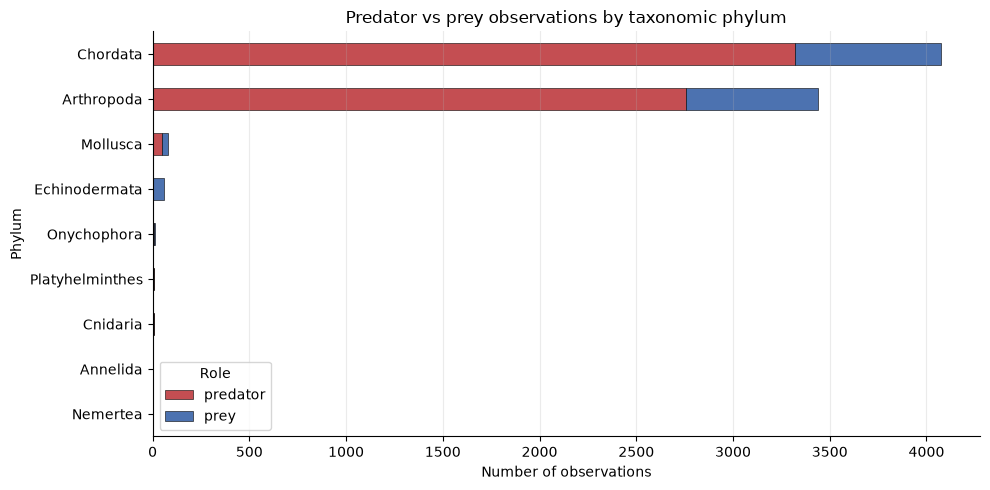

In [83]:
top_classes = phylum_role_obs.sort_values("total", ascending=False).head(12).index

plot_df = phylum_role_obs.loc[top_classes, ["predator", "prey"]]

fig, ax = plt.subplots(figsize=(10, 5))

plot_df.plot(
    kind="barh",
    stacked=True,
    ax=ax,
    color=["#C44E52", "#4C72B0"],
    edgecolor="black",
    linewidth=0.4,
)

ax.invert_yaxis()
ax.set_xlabel("Number of observations")
ax.set_ylabel("Phylum")
ax.set_title("Predator vs prey observations by taxonomic phylum")
ax.legend(title="Role")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="x", alpha=0.25)

plt.tight_layout()
plt.show()

### Is taxonomic diversity similar across the two roles?

In [84]:
taxonomic_diversity_by_role = role_df.groupby(role_col).agg(
    observations=("obs_id", "nunique"),
    images=("photo_id", "count"),
    classes=("class_name", "nunique"),
    orders=("order_name", "nunique"),
    families=("family_name", "nunique"),
    genera=("genus_name", "nunique"),
    species=("species_name", "nunique"),
)

taxonomic_diversity_by_role

,observations,images,classes,orders,families,genera,species
predator_prey_role,,,,,,,
predator,6153,18654,18,105,435,51,2319
prey,1526,4206,26,108,366,23,890


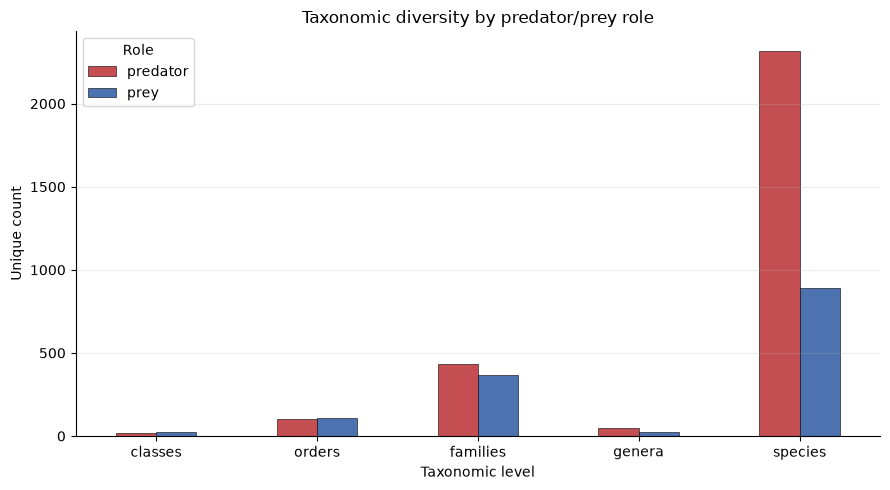

In [85]:
diversity_plot = taxonomic_diversity_by_role[
    ["classes", "orders", "families", "genera", "species"]
].T

fig, ax = plt.subplots(figsize=(9, 5))

diversity_plot.plot(
    kind="bar",
    ax=ax,
    color=["#C44E52", "#4C72B0"],
    edgecolor="black",
    linewidth=0.4,
)

ax.set_xlabel("Taxonomic level")
ax.set_ylabel("Unique count")
ax.set_title("Taxonomic diversity by predator/prey role")
ax.legend(title="Role")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="y", alpha=0.25)

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


### Is image count balanced between predator and prey?

In [86]:
obs_image_counts = (
    role_df.groupby([role_col, "obs_id"])
    .agg(images_per_observation=("photo_id", "count"))
    .reset_index()
)

image_balance_by_role = obs_image_counts.groupby(role_col).agg(
    observations=("obs_id", "nunique"),
    images=("images_per_observation", "sum"),
    mean_images_per_observation=("images_per_observation", "mean"),
    median_images_per_observation=("images_per_observation", "median"),
)

image_balance_by_role["image_share_percent"] = (
    image_balance_by_role["images"] / image_balance_by_role["images"].sum() * 100
)

image_balance_by_role

,observations,images,mean_images_per_observation,median_images_per_observation,image_share_percent
predator_prey_role,,,,,
predator,6153,18654,3.031692,2.0,81.60105
prey,1526,4206,2.756225,2.0,18.39895


## Geographic coverage


In [90]:
obs = animalia.drop_duplicates(subset="obs_id")
obs

,obs_id,photo_id,photo_license_code,url,obs_url,quality_grade,obs_license_code,predator_prey_role,scientific_name,taxon_rank,...,subfamily_name,hybrid_name,complex_name,form_name,subgenus_name,variety_name,tribe_name,country,state,city
2,338604,421440,cc-by-nc,https://inaturalist-open-data.s3.amazonaws.com...,http://conabio.inaturalist.org/observations/33...,research,cc-by-nc,predator,Geococcyx californianus,species,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Mexico,Coahuila,Torreón
6,414645,521779,cc-by,https://inaturalist-open-data.s3.amazonaws.com...,http://www.inaturalist.org/observations/414645,research,cc-by,predator,Lycophidion capense,species,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Zimbabwe,Mashonaland West Province,Hurungwe 7
8,414707,521820,cc-by,https://inaturalist-open-data.s3.amazonaws.com...,http://www.inaturalist.org/observations/414707,research,cc-by,prey,Mochlus sundevallii,species,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Zimbabwe,Mashonaland West Province,Hurungwe 7
9,420386,529902,cc-by-nc,https://inaturalist-open-data.s3.amazonaws.com...,http://www.inaturalist.org/observations/420386,research,cc-by-nc,NaN,Lampropeltis getula,species,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,United States,North Carolina,Orange
10,424251,534568,cc-by-nc,https://inaturalist-open-data.s3.amazonaws.com...,http://www.inaturalist.org/observations/424251,research,cc-by-nc,prey,Hemidactylus turcicus,species,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,United States,Texas,Hays
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28517,402861887,739605974,cc-by-nc,https://inaturalist-open-data.s3.amazonaws.com...,https://www.inaturalist.org/observations/40286...,research,cc-by-nc,predator,Mecaphesa asperata,species,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,United States,Pennsylvania,Franklin
28520,402870238,739612178,cc-by-nc-sa,https://inaturalist-open-data.s3.amazonaws.com...,https://www.inaturalist.org/observations/40287...,research,cc-by-nc-sa,predator,Buteo jamaicensis borealis,subspecies,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Canada,Ontario,Toronto
28528,402894441,739672663,cc-by-nc,https://inaturalist-open-data.s3.amazonaws.com...,https://www.inaturalist.org/observations/40289...,research,cc-by-nc,predator,Tenodera sinensis,species,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,United States,Massachusetts,Middlesex
28541,402961424,739804657,cc-by-nc,https://inaturalist-open-data.s3.amazonaws.com...,https://www.inaturalist.org/observations/40296...,research,cc-by-nc,predator,Cyprotides cyprotus,species,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Australia,New South Wales,Northern Beaches


In [97]:
obs[~obs["state"].isna() & (obs["state"] != "")].shape


(7810, 33)

### How many countries are represented?

In [88]:
country_dist = (
    animalia.groupby("country")["obs_id"]
    .nunique()
    .reset_index(name="observation_count")
    .sort_values(by="observation_count", ascending=False)
)

country_dist

,country,observation_count
111,United States,3619
92,South Africa,844
103,Thailand,440
117,Zimbabwe,342
15,Canada,281
...,...,...
107,Turkey,1
106,Trinidad and Tobago,1
112,Uruguay,1
113,Vanuatu,1


### What are the top 5 countries by observation count and their percentages?

In [98]:
country_dist["percentage"] = round(
    (country_dist["observation_count"] / country_dist["observation_count"].sum()) * 100,
    2,
)
country_dist.head()

,country,observation_count,percentage
111,United States,3619,46.29
92,South Africa,844,10.80
103,Thailand,440,5.63
117,Zimbabwe,342,4.37
15,Canada,281,3.59


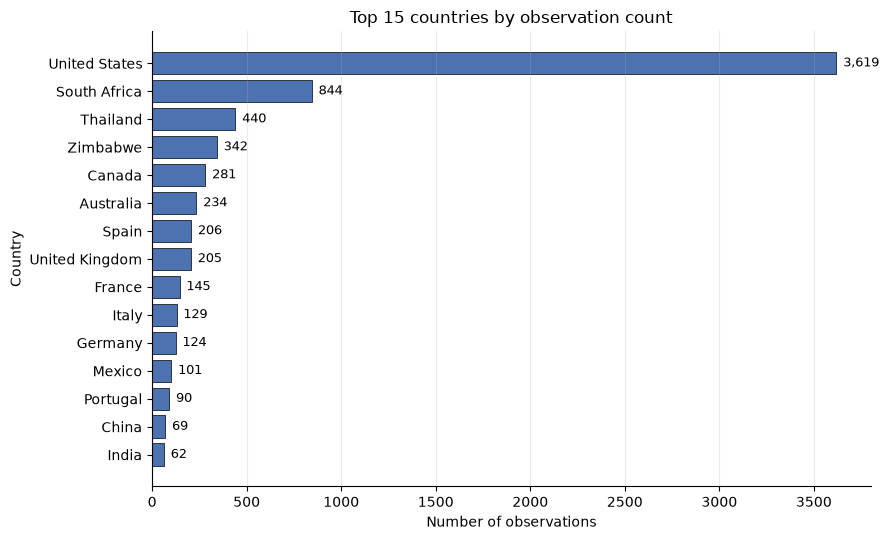

In [100]:
import matplotlib.pyplot as plt

top_n = 15

country_plot = country_dist.sort_values("observation_count", ascending=False).head(
    top_n
)

fig, ax = plt.subplots(figsize=(9, 5.5))

bars = ax.barh(
    country_plot["country"],
    country_plot["observation_count"],
    color="#4C72B0",
    edgecolor="black",
    linewidth=0.5,
)

ax.invert_yaxis()

ax.set_xlabel("Number of observations")
ax.set_ylabel("Country")
ax.set_title(f"Top {top_n} countries by observation count")

for bar, count in zip(bars, country_plot["observation_count"]):
    ax.text(
        count + country_plot["observation_count"].max() * 0.01,
        bar.get_y() + bar.get_height() / 2,
        f"{int(count):,}",
        va="center",
        fontsize=9,
    )

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="x", alpha=0.25)

plt.tight_layout()
plt.show()

### How geographically concentrated is the dataset?

In [15]:
country_col = "country"
obs_col = "obs_id"

In [16]:
# Geographic analysis dataframe

geo_df = animalia.copy()

geo_df[country_col] = (
    geo_df[country_col]
    .astype("string")
    .str.strip()
    .replace({"": pd.NA, "nan": pd.NA, "None": pd.NA})
)

usable_geo_df = geo_df.dropna(subset=[country_col])

In [17]:
# How geographically concentrated is the dataset?

country_dist = (
    usable_geo_df.groupby(country_col)
    .agg(
        observation_count=(obs_col, "nunique"),
        image_count=("photo_id", "nunique"),
        species_count=("species_name", "nunique"),
        class_count=("class_name", "nunique"),
        order_count=("order_name", "nunique"),
    )
    .sort_values("observation_count", ascending=False)
    .reset_index()
)

total_geo_observations = country_dist["observation_count"].sum()

country_dist["observation_share_percent"] = (
    country_dist["observation_count"] / total_geo_observations * 100
)

country_dist["cumulative_share_percent"] = country_dist[
    "observation_share_percent"
].cumsum()

print(f"Countries represented: {country_dist.shape[0]:,}")
print(
    f"Top 1 country share: {country_dist.head(1)['observation_share_percent'].sum():.2f}%"
)
print(
    f"Top 5 countries share: {country_dist.head(5)['observation_share_percent'].sum():.2f}%"
)
print(
    f"Top 10 countries share: {country_dist.head(10)['observation_share_percent'].sum():.2f}%"
)

country_dist.head(15)

Countries represented: 118
Top 1 country share: 46.29%
Top 5 countries share: 70.68%
Top 10 countries share: 82.44%


,country,observation_count,image_count,species_count,class_count,order_count,observation_share_percent,cumulative_share_percent
0,United States,3619,10153,1138,26,111,46.290611,46.290611
1,South Africa,844,4444,400,10,50,10.795600,57.086211
2,Thailand,440,1059,304,11,41,5.628038,62.714249
3,Zimbabwe,342,686,194,7,33,4.374520,67.088770
4,Canada,281,688,162,12,43,3.594270,70.683039
5,Australia,234,669,157,10,48,2.993093,73.676132
6,Spain,206,493,141,9,34,2.634945,76.311077
7,United Kingdom,205,593,102,10,34,2.622154,78.933231
8,France,145,295,74,8,26,1.854694,80.787925
9,Italy,129,283,81,9,30,1.650038,82.437964


### How many observations lack usable geographic metadata?

In [18]:
missing_geo_summary = pd.Series(
    {
        "total_observations": geo_df[obs_col].nunique(),
        "observations_with_country": usable_geo_df[obs_col].nunique(),
        "observations_missing_country": geo_df[geo_df[country_col].isna()][
            obs_col
        ].nunique(),
        "percent_missing_country": (
            geo_df[geo_df[country_col].isna()][obs_col].nunique()
            / geo_df[obs_col].nunique()
            * 100
        ),
    }
)

missing_geo_summary

total_observations              7832.000000
observations_with_country       7818.000000
observations_missing_country      14.000000
percent_missing_country            0.178754
dtype: float64

### Does taxonomic richness vary by geographic region?

In [20]:
geo_richness = (
    usable_geo_df.groupby(country_col)
    .agg(
        observations=(obs_col, "nunique"),
        images=("photo_id", "nunique"),
        classes=("class_name", "nunique"),
        orders=("order_name", "nunique"),
        families=("family_name", "nunique"),
        genera=("genus_name", "nunique"),
        species=("species_name", "nunique"),
    )
    .sort_values("species", ascending=False)
    .reset_index()
)

geo_richness["species_per_100_observations"] = round(
    geo_richness["species"] / geo_richness["observations"] * 100, 2
)

geo_richness.head(15)

,country,observations,images,classes,orders,families,genera,species,species_per_100_observations
0,United States,3619,10153,26,111,369,31,1138,31.45
1,South Africa,844,4444,10,50,172,6,400,47.39
2,Thailand,440,1059,11,41,106,0,304,69.09
3,Zimbabwe,342,686,7,33,99,0,194,56.73
4,Canada,281,688,12,43,100,1,162,57.65
5,Australia,234,669,10,48,104,3,157,67.09
6,Spain,206,493,9,34,85,2,141,68.45
7,United Kingdom,205,593,10,34,66,1,102,49.76
8,Germany,124,406,8,33,69,1,88,70.97
9,Italy,129,283,9,30,61,2,81,62.79


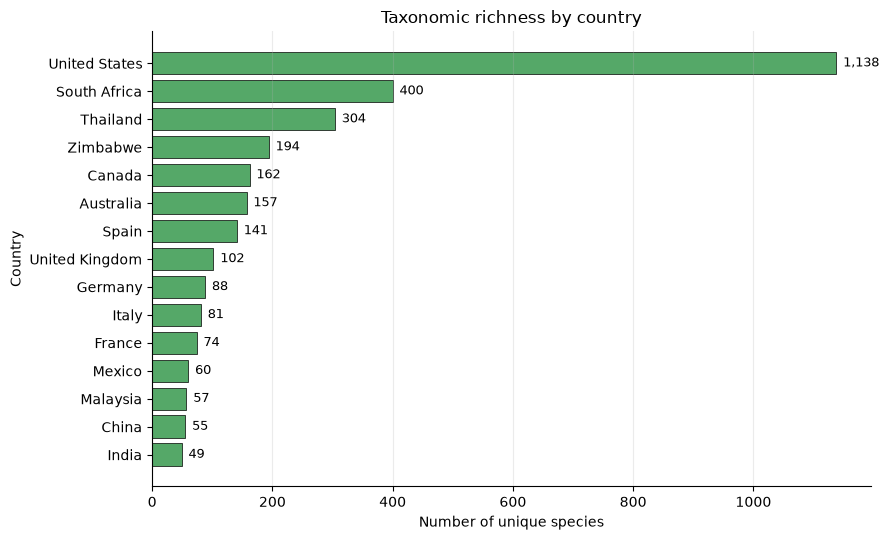

In [22]:
# Plot: species richness by country
import matplotlib.pyplot as plt

richness_plot = geo_richness.sort_values("species", ascending=False).head(15)

fig, ax = plt.subplots(figsize=(9, 5.5))

bars = ax.barh(
    richness_plot[country_col],
    richness_plot["species"],
    color="#55A868",
    edgecolor="black",
    linewidth=0.5,
)

ax.invert_yaxis()
ax.set_xlabel("Number of unique species")
ax.set_ylabel("Country")
ax.set_title("Taxonomic richness by country")

for bar, count in zip(bars, richness_plot["species"]):
    ax.text(
        count + richness_plot["species"].max() * 0.01,
        bar.get_y() + bar.get_height() / 2,
        f"{int(count):,}",
        va="center",
        fontsize=9,
    )

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="x", alpha=0.25)

plt.tight_layout()
plt.show()

### Are certain species heavily tied to particular countries?

In [23]:
species_country = (
    usable_geo_df.dropna(subset=["species_name"])
    .groupby(["species_name", country_col])
    .agg(observation_count=(obs_col, "nunique"))
    .reset_index()
)

In [24]:
species_total = (
    species_country.groupby("species_name")["observation_count"]
    .sum()
    .rename("species_total_observations")
)

In [25]:
species_country = species_country.merge(
    species_total,
    on="species_name",
    how="left",
)


In [26]:
species_country["country_share_percent"] = (
    species_country["observation_count"]
    / species_country["species_total_observations"]
    * 100
)

In [27]:
country_tied_species = (
    species_country.sort_values(
        ["species_name", "country_share_percent", "observation_count"],
        ascending=[True, False, False],
    )
    .groupby("species_name")
    .head(1)
    .query("species_total_observations >= 5 and country_share_percent >= 80")
    .sort_values(
        ["country_share_percent", "species_total_observations"],
        ascending=False,
    )
)

print(
    "Species with at least 5 observations where >=80% of observations "
    "come from one country:",
    country_tied_species.shape[0],
)

country_tied_species.head(20)

Species with at least 5 observations where >=80% of observations come from one country: 188


,species_name,country,observation_count,species_total_observations,country_share_percent
1559,Halcyon albiventris,South Africa,107,107,100.0
42,Aceria theospyri,United States,103,103,100.0
2416,Omphalocera munroei,United States,72,72,100.0
1395,Evasterias troschelii,United States,43,43,100.0
146,Alligator mississippiensis,United States,38,38,100.0
1338,Erythemis simplicicollis,United States,35,35,100.0
1857,Larus glaucescens,United States,29,29,100.0
2823,Platycryptus undatus,United States,29,29,100.0
2738,Phoenicopterus roseus,France,24,24,100.0
618,Buteo lineatus,United States,22,22,100.0


###  Is the dataset overwhelmingly North American or broadly global?

In [29]:
import numpy as np

north_america_countries = {
    "United States",
    "Canada",
    "Mexico",
    "Greenland",
    "Bermuda",
    "Saint Pierre and Miquelon",
}

country_dist["region_group"] = np.where(
    country_dist[country_col].isin(north_america_countries),
    "North America",
    "Outside North America",
)

region_summary = country_dist.groupby("region_group").agg(
    observations=("observation_count", "sum"),
    images=("image_count", "sum"),
    species=("species_count", "sum"),
    countries=(country_col, "nunique"),
)

region_summary["observation_share_percent"] = (
    region_summary["observations"] / region_summary["observations"].sum() * 100
)

region_summary

,observations,images,species,countries,observation_share_percent
region_group,,,,,
North America,4002,11165,1361,4,51.189563
Outside North America,3816,11874,2458,114,48.810437



## Long-tail and imbalance questions

In [30]:
# Species frequency summary

species_freq = (
    animalia.dropna(subset=["species_name"])
    .groupby("species_name")
    .agg(
        observation_count=("obs_id", "nunique"),
        image_count=("photo_id", "nunique"),
    )
    .sort_values("observation_count", ascending=False)
)

total_species = species_freq.shape[0]
total_observations = species_freq["observation_count"].sum()
total_images = species_freq["image_count"].sum()

median_obs_per_species = species_freq["observation_count"].median()
pct_species_under_5_obs = (species_freq["observation_count"] < 5).mean() * 100
most_common_species_obs_share = (
    species_freq["observation_count"].max() / total_observations * 100
)

print(f"Number of species: {total_species:,}")
print(f"Median observations per species: {median_obs_per_species:.0f}")
print(f"Species with fewer than 5 observations: {pct_species_under_5_obs:.2f}%")
print(f"Most common species observation share: {most_common_species_obs_share:.2f}%")

species_freq.head(10)

Number of species: 2,992
Median observations per species: 1
Species with fewer than 5 observations: 89.51%
Most common species observation share: 1.90%


,observation_count,image_count
species_name,,
Apis mellifera,145,302
Halcyon albiventris,107,460
Aceria theospyri,103,207
Pandion haliaetus,92,271
Ardea herodias,82,327
Passer domesticus,80,216
Omphalocera munroei,72,124
Turdus migratorius,45,96
Evasterias troschelii,43,53


### What is the Gini coefficient or another concentration statistic for species frequency?

In [31]:
# Gini coefficient for species observation frequency


def gini(values):
    values = np.asarray(values, dtype=float)
    values = values[~np.isnan(values)]

    if values.size == 0:
        return np.nan

    if np.any(values < 0):
        raise ValueError("Gini coefficient is not defined for negative values.")

    if values.sum() == 0:
        return 0

    sorted_values = np.sort(values)
    n = sorted_values.size
    cumulative = np.cumsum(sorted_values)

    return (n + 1 - 2 * np.sum(cumulative) / cumulative[-1]) / n


species_obs_gini = gini(species_freq["observation_count"])
species_image_gini = gini(species_freq["image_count"])

print(f"Gini coefficient, observations per species: {species_obs_gini:.3f}")
print(f"Gini coefficient, images per species: {species_image_gini:.3f}")

Gini coefficient, observations per species: 0.514
Gini coefficient, images per species: 0.603


### Image-level vs observation-level vs species-level distribution

In [32]:
# Image-level vs observation-level vs species-level distribution

distribution_summary = pd.DataFrame(
    {
        "level": ["Image-level", "Observation-level", "Species-level"],
        "unit_count": [
            total_images,
            total_observations,
            total_species,
        ],
        "median_per_species": [
            species_freq["image_count"].median(),
            species_freq["observation_count"].median(),
            1,
        ],
        "mean_per_species": [
            species_freq["image_count"].mean(),
            species_freq["observation_count"].mean(),
            1,
        ],
        "gini_by_species": [
            species_image_gini,
            species_obs_gini,
            0,
        ],
    }
)

distribution_summary

,level,unit_count,median_per_species,mean_per_species,gini_by_species
0,Image-level,22677,4.0,7.579211,0.602503
1,Observation-level,7647,1.0,2.555816,0.513719
2,Species-level,2992,1.0,1.000000,0.000000


need to check why is observation level 76467?

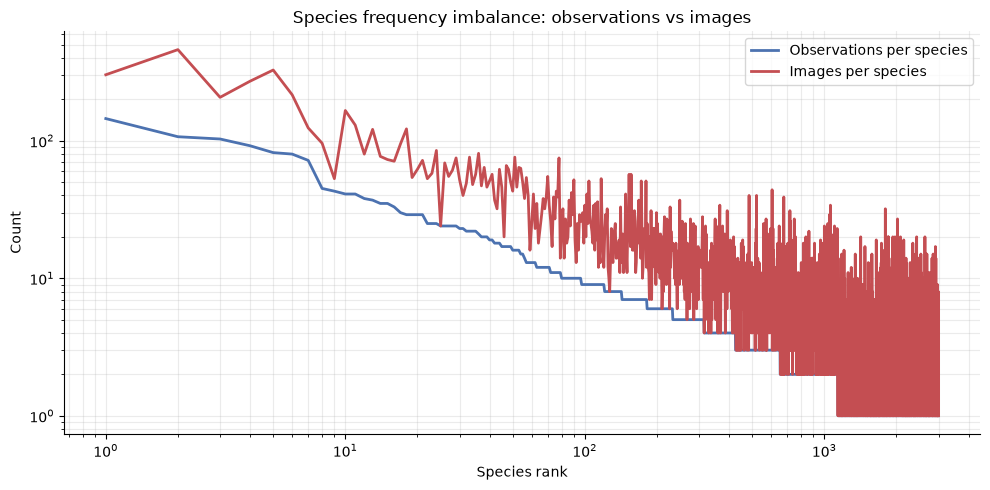

In [34]:
# Plot: image-level vs observation-level species imbalance

plot_df = species_freq.reset_index(drop=True).copy()
plot_df["species_rank"] = np.arange(1, len(plot_df) + 1)

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(
    plot_df["species_rank"],
    plot_df["observation_count"],
    label="Observations per species",
    color="#4C72B0",
    linewidth=2,
)

ax.plot(
    plot_df["species_rank"],
    plot_df["image_count"],
    label="Images per species",
    color="#C44E52",
    linewidth=2,
)

ax.set_xscale("log")
ax.set_yscale("log")

ax.set_xlabel("Species rank")
ax.set_ylabel("Count")
ax.set_title("Species frequency imbalance: observations vs images")
ax.legend()

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(True, which="both", alpha=0.25)

plt.tight_layout()
plt.show()

### Top species share at image and observation level

In [35]:
# Top species share at image and observation level

top_species_share = pd.DataFrame(
    {
        "metric": [
            "Top 1 species observation share",
            "Top 1 species image share",
            "Top 5 species observation share",
            "Top 5 species image share",
            "Top 10 species observation share",
            "Top 10 species image share",
        ],
        "percent": [
            species_freq.head(1)["observation_count"].sum() / total_observations * 100,
            species_freq.head(1)["image_count"].sum() / total_images * 100,
            species_freq.head(5)["observation_count"].sum() / total_observations * 100,
            species_freq.head(5)["image_count"].sum() / total_images * 100,
            species_freq.head(10)["observation_count"].sum() / total_observations * 100,
            species_freq.head(10)["image_count"].sum() / total_images * 100,
        ],
    }
)

top_species_share

,metric,percent
0,Top 1 species observation share,1.896168
1,Top 1 species image share,1.331746
2,Top 5 species observation share,6.917746
3,Top 5 species image share,6.910085
4,Top 10 species observation share,10.592389
5,Top 10 species image share,9.798474


### Which taxonomic levels are most imbalanced?

In [36]:
# Which taxonomic levels are most imbalanced?

taxonomic_levels = [
    "class_name",
    "order_name",
    "family_name",
    "genus_name",
    "species_name",
]

imbalance_rows = []

for level in taxonomic_levels:
    if level not in animalia.columns:
        continue

    level_counts = (
        animalia.dropna(subset=[level])
        .groupby(level)
        .agg(
            observation_count=("obs_id", "nunique"),
            image_count=("photo_id", "count"),
        )
    )

    total_level_obs = level_counts["observation_count"].sum()
    total_level_images = level_counts["image_count"].sum()

    imbalance_rows.append(
        {
            "taxonomic_level": level.replace("_name", ""),
            "unique_groups": level_counts.shape[0],
            "median_observations_per_group": level_counts["observation_count"].median(),
            "max_observations_in_one_group": level_counts["observation_count"].max(),
            "top_group_observation_share_percent": (
                level_counts["observation_count"].max() / total_level_obs * 100
            ),
            "top_5_group_observation_share_percent": (
                level_counts["observation_count"]
                .sort_values(ascending=False)
                .head(5)
                .sum()
                / total_level_obs
                * 100
            ),
            "observation_gini": gini(level_counts["observation_count"]),
            "image_gini": gini(level_counts["image_count"]),
        }
    )

taxonomic_imbalance = pd.DataFrame(imbalance_rows).sort_values(
    "observation_gini", ascending=False
)

taxonomic_imbalance

,taxonomic_level,unique_groups,median_observations_per_group,max_observations_in_one_group,top_group_observation_share_percent,top_5_group_observation_share_percent,observation_gini,image_gini
0,class,29,7.0,2743,35.108153,91.565340,0.856486,0.862032
1,order,144,5.5,962,12.300217,44.764097,0.825066,0.831865
2,family,613,3.0,378,4.826970,15.783425,0.745448,0.754449
4,species,2992,1.0,145,1.896168,6.917746,0.513719,0.602503
3,genus,69,1.0,6,6.000000,21.000000,0.259130,0.372497


# Summary

In [140]:
print(f"The number of records in the dataset is {animalia.shape[0]}")
print(f"Final Total number of columns in the dataset: {animalia.shape[1]}")
print(f"Number of unique observations in the dataset is {animalia['obs_id'].nunique()}")
print(f"Number of images in the dataset: {animalia['photo_id'].count()}")
print(f"Photo count distribution:\n{photo_count_summary}")
print(f"Mean photo count per observation: {photo_dist.loc['mean', 'photo_count']}")
print(f"Median photo count per observation: {photo_dist.loc['50%', 'photo_count']}")
print(f"Maximum photo count per observation: {photo_dist.loc['max', 'photo_count']}")
print(f"Minimum photo count per observation: {photo_dist.loc['min', 'photo_count']}")

print(f"Observation license code distribution is:\n{obs_license_distribution}")
print(f"Unsupported licenses count: {unsupported_licenses_count}")
print(
    f"Missing species label count: {animalia[animalia['scientific_name'].isna() | (animalia['scientific_name'] == '')].shape[0]}"
)
print(
    f"Missing photos count: {animalia[animalia['photo_count'].isna() | (animalia['photo_count'] == 0)].shape[0]}"
)
print(f"Duplicate observations count: {animalia.duplicated(subset=['obs_id']).sum()}")

The number of records in the dataset is 23125
Final Total number of columns in the dataset: 33
Number of unique observations in the dataset is 7832
Number of images in the dataset: 23125
Photo count distribution:
1     2971
2     1693
3+    3168
dtype: int64
Mean photo count per observation: 2.9526302349336055
Median photo count per observation: 2.0
Maximum photo count per observation: 33.0
Minimum photo count per observation: 1.0
Observation license code distribution is:
  obs_license_code  count
0         cc-by-nc   4842
1            cc-by   2395
2              cc0    341
3      cc-by-nc-nd    125
4      cc-by-nc-sa     92
5         cc-by-sa     35
6         cc-by-nd      2
Unsupported licenses count: 0
Missing species label count: 0
Missing photos count: 0
Duplicate observations count: 15293


In [141]:
animalia.columns

Index(['obs_id', 'photo_id', 'photo_license_code', 'url', 'obs_url',
       'quality_grade', 'obs_license_code', 'predator_prey_role',
       'scientific_name', 'taxon_rank', 'common_name', 'latitude', 'longitude',
       'positional_accuracy', 'photo_count', 'kingdom_name', 'phylum_name',
       'class_name', 'order_name', 'family_name', 'genus_name', 'species_name',
       'subspecies_name', 'subfamily_name', 'hybrid_name', 'complex_name',
       'form_name', 'subgenus_name', 'variety_name', 'tribe_name', 'country',
       'state', 'city'],
      dtype='str')

In [ ]:
animalia.rename(columns={"url": "photo_url"}, inplace=True)

# save the file

In [142]:
animalia.to_parquet("../data/processed/dataset.parquet", index=False)

In [143]:
animalia.to_csv("../data/processed/dataset_human_review.csv", index=False)

In [2]:
import pandas as pd

animalia = pd.read_csv("../data/processed/dataset_human_review.csv")
animalia.head()

C:\Users\surab\AppData\Local\Temp\ipykernel_17576\2418522853.py:3: DtypeWarning: Columns (23: subfamily_name, 26: form_name) have mixed types. Specify dtype option on import or set low_memory=False.
  animalia = pd.read_csv("../data/processed/dataset_human_review.csv")


,obs_id,photo_id,photo_license_code,url,obs_url,quality_grade,obs_license_code,predator_prey_role,scientific_name,taxon_rank,...,subfamily_name,hybrid_name,complex_name,form_name,subgenus_name,variety_name,tribe_name,country,state,city
0,338604,421440,cc-by-nc,https://inaturalist-open-data.s3.amazonaws.com...,http://conabio.inaturalist.org/observations/33...,research,cc-by-nc,predator,Geococcyx californianus,species,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Mexico,Coahuila,Torreón
1,338604,421441,cc-by-nc,https://inaturalist-open-data.s3.amazonaws.com...,http://conabio.inaturalist.org/observations/33...,research,cc-by-nc,predator,Geococcyx californianus,species,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Mexico,Coahuila,Torreón
2,338604,421442,cc-by-nc,https://inaturalist-open-data.s3.amazonaws.com...,http://conabio.inaturalist.org/observations/33...,research,cc-by-nc,predator,Geococcyx californianus,species,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Mexico,Coahuila,Torreón
3,338604,421443,cc-by-nc,https://inaturalist-open-data.s3.amazonaws.com...,http://conabio.inaturalist.org/observations/33...,research,cc-by-nc,predator,Geococcyx californianus,species,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Mexico,Coahuila,Torreón
4,414645,521779,cc-by,https://inaturalist-open-data.s3.amazonaws.com...,http://www.inaturalist.org/observations/414645,research,cc-by,predator,Lycophidion capense,species,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Zimbabwe,Mashonaland West Province,Hurungwe 7
